# Blockwise Randomized Hadamard Transform

Author: Nimitt \
Email: nimitt.nimitt@iitgn.ac.in

Consider $S$, a $(d,b)$-BRHT. With probability at least $1/2$,

$$
 ||(S\mu)_{[0:2(d/b)]}||_2^2 \gt \frac{||\mu||_2^2}{20b}
$$

In this notebook we emperically test this bound.

## Importing Libraries

In [ ]:
import numpy as np
from scipy.linalg import hadamard
import matplotlib.pyplot as plt

Vector norm ||x|| = 100.0000
Block size = 4
Empirical E[Z]: 5033.6906
Empirical Var[Z]: 1283616.5315
Empirical E[Z^2]: 26621658.0747
Theoretical E[Z]: 2500.0000
Theoretical upper bound on E[Z^2]: 18750000.0000


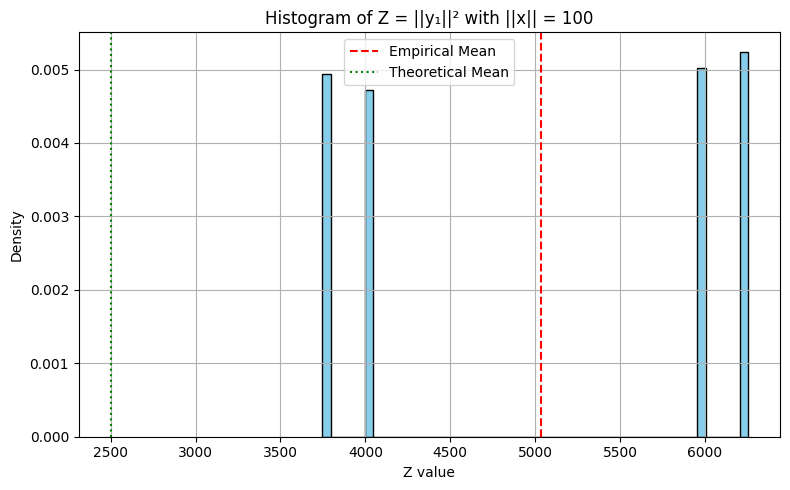

1.0
4


In [ ]:
def block_randomized_transform(x, b):
    d = len(x)
    assert d % b == 0, "d must be divisible by b"
    block_size = d // b

    # Generate block-wise Rademacher vector
    epsilons = np.random.choice([-1, 1], size=b)

    # Construct Dx (block-wise sign flips)
    Dx = np.zeros_like(x)
    for i in range(b):
        Dx[i * block_size : (i+1) * block_size] = epsilons[i] * x[i * block_size : (i+1) * block_size]

    # Apply normalized Hadamard transform
    H = hadamard(d) / np.sqrt(d)
    y = H @ Dx

    # Return energy in first block
    y1 = y[:2*block_size]
    return np.linalg.norm(y1)**2

# Parameters
d = 16    # dimension (must be power of 2)
b = 4  # number of blocks
R = 100        # desired L2 norm of x
num_trials = 1000

# Generate x with norm = R
x = np.random.randn(d)
x = R * x / np.linalg.norm(x)
block_size = d // b

# Run trials
Z_vals = np.array([block_randomized_transform(x, b) for _ in range(num_trials)])

# Compute stats
empirical_mean = np.mean(Z_vals)
empirical_var = np.var(Z_vals)
empirical_second_moment = np.mean(Z_vals**2)
theoretical_mean = R**2 / b
theoretical_second_moment_bound = (3 / b**2) * R**4

# Print stats
print(f"Vector norm ||x|| = {np.linalg.norm(x):.4f}")
print(f"Block size = {block_size}")
print(f"Empirical E[Z]: {empirical_mean:.4f}")
print(f"Empirical Var[Z]: {empirical_var:.4f}")
print(f"Empirical E[Z^2]: {empirical_second_moment:.4f}")
print(f"Theoretical E[Z]: {theoretical_mean:.4f}")
print(f"Theoretical upper bound on E[Z^2]: {theoretical_second_moment_bound:.4f}")

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(Z_vals, bins=50, color='skyblue', edgecolor='black', density=True)
plt.axvline(empirical_mean, color='red', linestyle='--', label='Empirical Mean')
plt.axvline(theoretical_mean, color='green', linestyle=':', label='Theoretical Mean')
plt.title(f"Histogram of Z = ||y₁||² with ||x|| = {R}")
plt.xlabel("Z value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print((Z_vals > 0.29*theoretical_mean).sum()/num_trials)
print(len(np.unique(Z_vals)))

## Illustrations for Proof

In [ ]:
d = 16
b = 4
m = d//b

H = hadamard(d) 
print("Hadamard")
print(H)
count = 0
mat = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        sum = 0
        for k in range(0,2*m):
            sum+= H[k][i]*H[k][j]
        mat[i][j] = sum

ds = np.empty(d)
for i in range(b):
    ds[i*m:(i+1)*m] = (i+1)*np.ones(m)

map = {}
for i in range(d):
    for j in range(i, d):
        if mat[i][j]:
            key = f"d{int(ds[i])}d{int(ds[j])}"
            term = f"+ x{i+1}x{j+1}"
            if key in map:
                map[key] += term
            else:
                map[key] = term

print("\nExpansion of Z:")
print(mat)
print("\nZ - e^2/b")
map


Hadamard
[[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 1 -1  1 -1  1 -1  1 -1  1 -1  1 -1  1 -1  1 -1]
 [ 1  1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1 -1 -1]
 [ 1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1 -1 -1  1]
 [ 1  1  1  1 -1 -1 -1 -1  1  1  1  1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1]
 [ 1  1 -1 -1 -1 -1  1  1  1  1 -1 -1 -1 -1  1  1]
 [ 1 -1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1 -1]
 [ 1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1]
 [ 1 -1  1 -1  1 -1  1 -1 -1  1 -1  1 -1  1 -1  1]
 [ 1  1 -1 -1  1  1 -1 -1 -1 -1  1  1 -1 -1  1  1]
 [ 1 -1 -1  1  1 -1 -1  1 -1  1  1 -1 -1  1  1 -1]
 [ 1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1]
 [ 1 -1  1 -1 -1  1 -1  1 -1  1 -1  1  1 -1  1 -1]
 [ 1  1 -1 -1 -1 -1  1  1 -1 -1  1  1  1  1 -1 -1]
 [ 1 -1 -1  1 -1  1  1 -1 -1  1  1 -1  1 -1 -1  1]]

Expansion of Z:
[[8. 0. 0. 0. 0. 0. 0. 0. 8. 0. 0. 0. 0. 0. 0. 0.]
 [0. 8. 0. 0. 0. 0. 0. 0. 0. 8. 0. 0. 0. 0. 0. 0.]
 [0. 0. 8. 0. 0. 0. 0. 0. 0. 0. 8. 0. 0. 0. 0. 0.]
 [0.

{'d1d1': '+ x1x1+ x2x2+ x3x3+ x4x4',
 'd1d3': '+ x1x9+ x2x10+ x3x11+ x4x12',
 'd2d2': '+ x5x5+ x6x6+ x7x7+ x8x8',
 'd2d4': '+ x5x13+ x6x14+ x7x15+ x8x16',
 'd3d3': '+ x9x9+ x10x10+ x11x11+ x12x12',
 'd4d4': '+ x13x13+ x14x14+ x15x15+ x16x16'}